#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [4]:
no2_df = pd.read_csv("/content/drive/MyDrive/TA/Dataset/no2.csv")
no2_sea = pd.read_csv("/content/drive/MyDrive/TA/Dataset/Sea/NO2_Sea_cleaned.csv")

# Merge data CO and NO2 among years

In [ ]:
# years = range(2023, 2026)

# co_dfs = []
# no2_dfs = []

# for year in years:
#     co_path = f"/content/drive/MyDrive/TA/Dataset/co_{year}_cleaned.csv"
#     no2_path = f"/content/drive/MyDrive/TA/Dataset/no2_{year}_cleaned.csv"

#     try:
#         co_df = pd.read_csv(co_path)
#         no2_df = pd.read_csv(no2_path)

#         co_dfs.append(co_df)
#         no2_dfs.append(no2_df)

#         print(f"Loaded data for {year}")

#     except FileNotFoundError:
#         print(f"File not found for {year}, skipping.")

# co_all = pd.concat(co_dfs, ignore_index=True)
# no2_all = pd.concat(no2_dfs, ignore_index=True)

# # Show results
# print("CO dataset shape:", co_all.shape)
# print("NO2 dataset shape:", no2_all.shape)

# co_all = co_all[["x_coord", "y_coord", "interval_from", "default_CO_mean","city"]]
# no2_all = no2_all[["x_coord", "y_coord", "interval_from", "default_NO2_mean","city"]]

# co_all = co_all.rename(columns={
#     "interval_from": "date",
#     "default_CO_mean": "CO_mean"
# })

# no2_all = no2_all.rename(columns={
#     "interval_from": "date",
#     "default_NO2_mean": "NO2_mean"
# })

# co_all.to_csv(dir+"/co.csv")

# no2_all.to_csv(dir+"/no2.csv")

#2. Class Definition

In [5]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)



class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Use RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='swish',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        # self.fourier_features = FourierFeatureMapping(mapping_size=mapping_size, sigma=sigma, trainable_B=trainable_B)

        # dummy_input = tf.keras.Input(shape=(3,))
        # _ = self.fourier_features(dummy_input)

        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is a Tensor
        X = tf.reshape(X, (-1, 3))  # Ensure input is 2D (batch_size, features) for [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z)
        for i in range(self.num_hidden_layers):
            Z = self.hidden[i](Z)
        return self.out(Z)


class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self):
        return self.get_r_fn(t=self.t, x=self.x, y=self.y, model=self.model, lambd = self.lambd, fun_r=self.fun_r)

    def loss_fn(self, X, u):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        r = self.get_r()
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u):
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)

        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, inverse=True, N=None, min_loss=None, timeout=None):
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is Tensor
        u = tf.convert_to_tensor(u, dtype=tf.float32)  # Ensure u is Tensor

        @tf.function
        def train_step():
          loss, grads = self.get_grad(X, u)
          optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
          return loss

        def loss_callback():
            loss = train_step()
            self.current_loss = loss.numpy()

            print(f"Iteration {self.iter}, Loss: {self.current_loss}")
            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        if timeout is not None:
            while time.time() - start_time < timeout:
                loss_callback()
        elif N is not None:
            for _ in range(N):
                loss_callback()
        elif min_loss is not None:
            while self.current_loss > min_loss:
                loss_callback()

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]

    #     # Reshape into [Nt+1, Nx+1, Ny+1]
    # Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
    # U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

    #     # Create meshgrid for visualization
    # T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
    # self.T_pred, self.X_pred, self.Y_pred = T, X, Y

    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

def plot_solution_slice(U, T, X, Y, time_idx=0):
    """Plot solution slice at specific time index"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X[time_idx], Y[time_idx], U[time_idx],
                          cmap='viridis', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(t,x,y)')
    ax.set_title(f'Solution at t = {T[time_idx,0,0]:.2f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        # Call init of base class
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)  # Ensure layers are initialized
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        # Combine neural network weights with lambda parameter
        return super().trainable_variables + [self.lambd]

class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param, X, u,
                               N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None, modified=False, **kwargs):
        self.changed = False
        self.lambd_list = []
        super().solve_with_TFoptimizer(optim_fwd, X, u, N=N_fwd, min_loss=min_loss_fwd, timeout=timeout_fwd, **kwargs)

        # Add parameters after fitting
        # with given data.
        self.model.add_param()
        self.changed = True

        print('\n\nFinding PDE parameters.')

        if modified is True:

            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param()

                # Perform gradient descent step, update the weights of the model.
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss

            def loss_callback():
                loss = train_step_param()

                self.current_loss = loss.numpy()
                callback()

        else:
            @tf.function
            def train_step_param_unmodified():
                 with tf.GradientTape() as tape:
                    tape.watch(self.model.lambd)
                    # phi_r is calculated only after
                    # variables are added.
                    # Compute phi_r
                    r = self.get_r()
                    loss = r

                 grad_lambd = tape.gradient(loss, self.model.lambd)
                 optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                 return loss


            def loss_callback():
                loss = train_step_param_unmodified()
                self.current_loss = loss.numpy()
                callback()



        def callback():
                lambd = self.model.lambd.numpy()
                self.model.lambd_list.append(lambd)

                if self.iter % 10 == 0:
                    print('It {:05d}: loss = {:10.8e} lambda = '.format(self.iter, self.current_loss) + str(lambd))

                self.hist.append(self.current_loss)
                self.iter += 1

        if N_param is not None:
            for _ in range(N_param):
                loss_callback()

            print ('{} iterations reached.'.format(N_param))

        elif min_loss_param is not None:
            while True:
                loss_callback()

                if self.current_loss < min_loss_param:
                    print ('Loss is reached. Current loss: {:10.8e}'.format(self.current_loss))
                    break

        elif timeout_param is not None:
            t0 = time.time()
            stop_after = time.time() + timeout_param

            while True:
                loss_callback()

                if time.time() > stop_after:
                    print ('Timeout is reached. Time elapsed: {} seconds'.format(time.time()-t0))
                    break

    def loss_fn(self, X, u):
        # Initialize loss
        loss = 0
        phi_r = 0

        # phi_r is calculated only after
        # variables are added.
        if self.changed is not False:
            # Compute phi_r
            r = self.get_r()
            phi_r =r
            loss += phi_r

        else:
            u_pred = self.model(X)
            loss += tf.reduce_mean(tf.square(u - u_pred))

        return loss, phi_r

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
            # print('It {:05d}: loss = {:10.8e}'.format(self.iter,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

# 3. Data PreProcessing and Training-Testing Split

In [6]:
no2_df

,Unnamed: 0,x_coord,y_coord,date,NO2_mean,city
0,0,107.610720,-7.100013,2023-01-01,NaN,Bandung
1,1,106.166337,-6.123216,2023-01-01,NaN,KotaSerang
2,2,107.157774,-7.133965,2023-01-01,0.000014,Cianjur
3,3,106.651931,-6.182884,2023-01-01,NaN,KotaTangerang
4,4,106.212780,-6.642310,2023-01-01,0.000014,Lebak
...,...,...,...,...,...,...
33840,33840,107.980880,-6.825126,2025-04-29,0.000016,Sumedang
33841,33841,107.414924,-6.897186,2025-04-29,0.000042,BandungBarat
33842,33842,108.141338,-7.497079,2025-04-29,0.000009,Tasikmalaya
33843,33843,107.432169,-6.595011,2025-04-29,0.000046,Purwakarta


In [7]:
no2_df.describe()

,Unnamed: 0,x_coord,y_coord,NO2_mean
count,33845.000000,33845.000000,33845.000000,22223.000000
mean,16922.000000,107.272484,-6.646184,0.000050
std,9770.354267,0.772219,0.422948,0.000047
min,0.000000,105.742952,-7.497079,-0.000030
25%,8461.000000,106.767609,-6.939855,0.000021
50%,16922.000000,107.157774,-6.595011,0.000034
75%,25383.000000,107.980880,-6.255422,0.000063
max,33844.000000,108.566579,-5.998129,0.000787


In [8]:
no2_sea

,Unnamed: 0,date,MeanNO2,longitude,latitude
0,0,2023-05-01,1.048124e-05,105.023528,-6.842984
1,1,2023-05-01,6.407810e-06,105.003719,-6.767207
2,2,2023-05-01,8.490805e-08,104.974697,-6.678569
3,3,2023-05-01,5.396200e-06,104.968469,-6.583673
4,4,2023-05-01,1.329365e-05,104.985761,-6.490722
...,...,...,...,...,...
172285,173860,2025-04-29,1.694724e-05,108.959799,-6.977997
172286,173861,2025-04-29,2.544793e-05,108.974448,-6.876551
172287,173862,2025-04-29,2.909901e-05,108.980321,-6.781030
172288,173863,2025-04-29,1.914681e-05,108.967292,-6.688445


In [9]:
no2_sea.describe()

,Unnamed: 0,MeanNO2,longitude,latitude
count,172290.000000,1.722900e+05,172290.000000,172290.000000
mean,86841.199362,2.450492e-05,107.080567,-6.749284
std,50145.194642,2.589195e-05,1.246113,0.703051
min,0.000000,2.033114e-09,104.968469,-7.964794
25%,43424.250000,1.228545e-05,105.958325,-7.463549
50%,86886.500000,1.824984e-05,106.993846,-6.688445
75%,130255.750000,2.737858e-05,108.363063,-6.084429
max,173864.000000,7.326844e-04,108.980321,-5.627853


In [10]:
no2_df = no2_df.drop(columns=['Unnamed: 0'])
no2_sea = no2_sea.drop(columns=['Unnamed: 0'])
no2_df.dropna(inplace = True)

In [11]:
no2_df['date'] = pd.to_datetime(no2_df['date'])
start_date = datetime.datetime(2023, 5, 1)
no2_df = no2_df[(no2_df['date'] >= start_date)]

no2_sea['date'] = pd.to_datetime(no2_sea['date'])
start_date = datetime.datetime(2023, 5, 1)
no2_sea = no2_sea[(no2_sea['date'] >= start_date)]
no2_sea.sort_values(by=['date','longitude','latitude'], inplace=True)

In [12]:
no2_df = no2_df[no2_df.NO2_mean>=0]
no2_sea = no2_sea[no2_sea.MeanNO2>=0]


In [13]:
no2_sea.rename(columns={'longitude':'x_coord', 'latitude':'y_coord',"MeanNO2":"NO2_mean"}, inplace=True)

In [14]:
no2_df

,x_coord,y_coord,date,NO2_mean,city
4795,106.166337,-6.123216,2023-05-01,0.000039,KotaSerang
4798,107.414924,-6.897186,2023-05-01,0.000026,BandungBarat
4800,106.651931,-6.182884,2023-05-01,0.000092,KotaTangerang
4801,107.788766,-7.359739,2023-05-01,0.000026,Garut
4802,108.466208,-7.434468,2023-05-01,0.000056,Ciamis
...,...,...,...,...,...
33840,107.980880,-6.825126,2025-04-29,0.000016,Sumedang
33841,107.414924,-6.897186,2025-04-29,0.000042,BandungBarat
33842,108.141338,-7.497079,2025-04-29,0.000009,Tasikmalaya
33843,107.432169,-6.595011,2025-04-29,0.000046,Purwakarta


In [15]:
no2_df.describe()

,x_coord,y_coord,date,NO2_mean
count,19438.000000,19438.000000,19438,1.943800e+04
mean,107.289350,-6.651296,2024-03-27 06:19:44.566313472,5.175490e-05
min,105.742952,-7.497079,2023-05-01 00:00:00,6.683333e-08
25%,106.748292,-6.939855,2023-09-24 00:00:00,2.170811e-05
50%,107.157774,-6.595011,2024-03-31 00:00:00,3.465232e-05
75%,107.980880,-6.252177,2024-09-06 00:00:00,6.584441e-05
max,108.566579,-5.998129,2025-04-29 00:00:00,7.873459e-04
std,0.794450,0.428976,NaN,4.818997e-05


In [16]:
no2_sea

,date,NO2_mean,x_coord,y_coord
3,2023-05-01,5.396200e-06,104.968469,-6.583673
2,2023-05-01,8.490805e-08,104.974697,-6.678569
4,2023-05-01,1.329365e-05,104.985761,-6.490722
1,2023-05-01,6.407810e-06,105.003719,-6.767207
5,2023-05-01,9.833321e-06,105.014849,-6.423209
...,...,...,...,...
172285,2025-04-29,1.694724e-05,108.959799,-6.977997
172279,2025-04-29,1.329156e-05,108.960063,-7.670531
172288,2025-04-29,1.914681e-05,108.967292,-6.688445
172286,2025-04-29,2.544793e-05,108.974448,-6.876551


In [17]:
no2_sea.describe()

,date,NO2_mean,x_coord,y_coord
count,172290,1.722900e+05,172290.000000,172290.000000
mean,2024-04-01 10:50:12.139996672,2.450492e-05,107.080567,-6.749284
min,2023-05-01 00:00:00,2.033114e-09,104.968469,-7.964794
25%,2023-09-29 00:00:00,1.228545e-05,105.958325,-7.463549
50%,2024-04-06 00:00:00,1.824984e-05,106.993846,-6.688445
75%,2024-09-11 00:00:00,2.737858e-05,108.363063,-6.084429
max,2025-04-29 00:00:00,7.326844e-04,108.980321,-5.627853
std,NaN,2.589195e-05,1.246113,0.703051


In [18]:
 df=pd.concat([no2_df, no2_sea], axis=0)

In [19]:
df.city = df.city.fillna('Sea')

In [20]:
df

,x_coord,y_coord,date,NO2_mean,city
4795,106.166337,-6.123216,2023-05-01,0.000039,KotaSerang
4798,107.414924,-6.897186,2023-05-01,0.000026,BandungBarat
4800,106.651931,-6.182884,2023-05-01,0.000092,KotaTangerang
4801,107.788766,-7.359739,2023-05-01,0.000026,Garut
4802,108.466208,-7.434468,2023-05-01,0.000056,Ciamis
...,...,...,...,...,...
172285,108.959799,-6.977997,2025-04-29,0.000017,Sea
172279,108.960063,-7.670531,2025-04-29,0.000013,Sea
172288,108.967292,-6.688445,2025-04-29,0.000019,Sea
172286,108.974448,-6.876551,2025-04-29,0.000025,Sea


In [21]:
df.describe(include="all")

,x_coord,y_coord,date,NO2_mean,city
count,191728.000000,191728.000000,191728,1.917280e+05,191728
unique,NaN,NaN,NaN,NaN,41
top,NaN,NaN,NaN,NaN,Sea
freq,NaN,NaN,NaN,NaN,172290
mean,107.101734,-6.739350,2024-03-31 22:12:49.389969408,2.726761e-05,NaN
min,104.968469,-7.964794,2023-05-01 00:00:00,2.033114e-09,NaN
25%,106.082504,-7.370404,2023-09-29 00:00:00,1.273526e-05,NaN
50%,107.101275,-6.681646,2024-04-05 00:00:00,1.917604e-05,NaN
75%,108.240269,-6.094171,2024-09-11 00:00:00,2.967739e-05,NaN
max,108.980321,-5.627853,2025-04-29 00:00:00,7.873459e-04,NaN


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# Membuat geometry Point dari koordinat
geometry = [Point(xy) for xy in zip(df['x_coord'], df['y_coord'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Mendapatkan peta dasar Indonesia
# Download dari Natural Earth (lakukan sekali saja)
# world = gpd.read_file('https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip')

# Alternatif: Gunakan data provinsi Indonesia dari GADM
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')


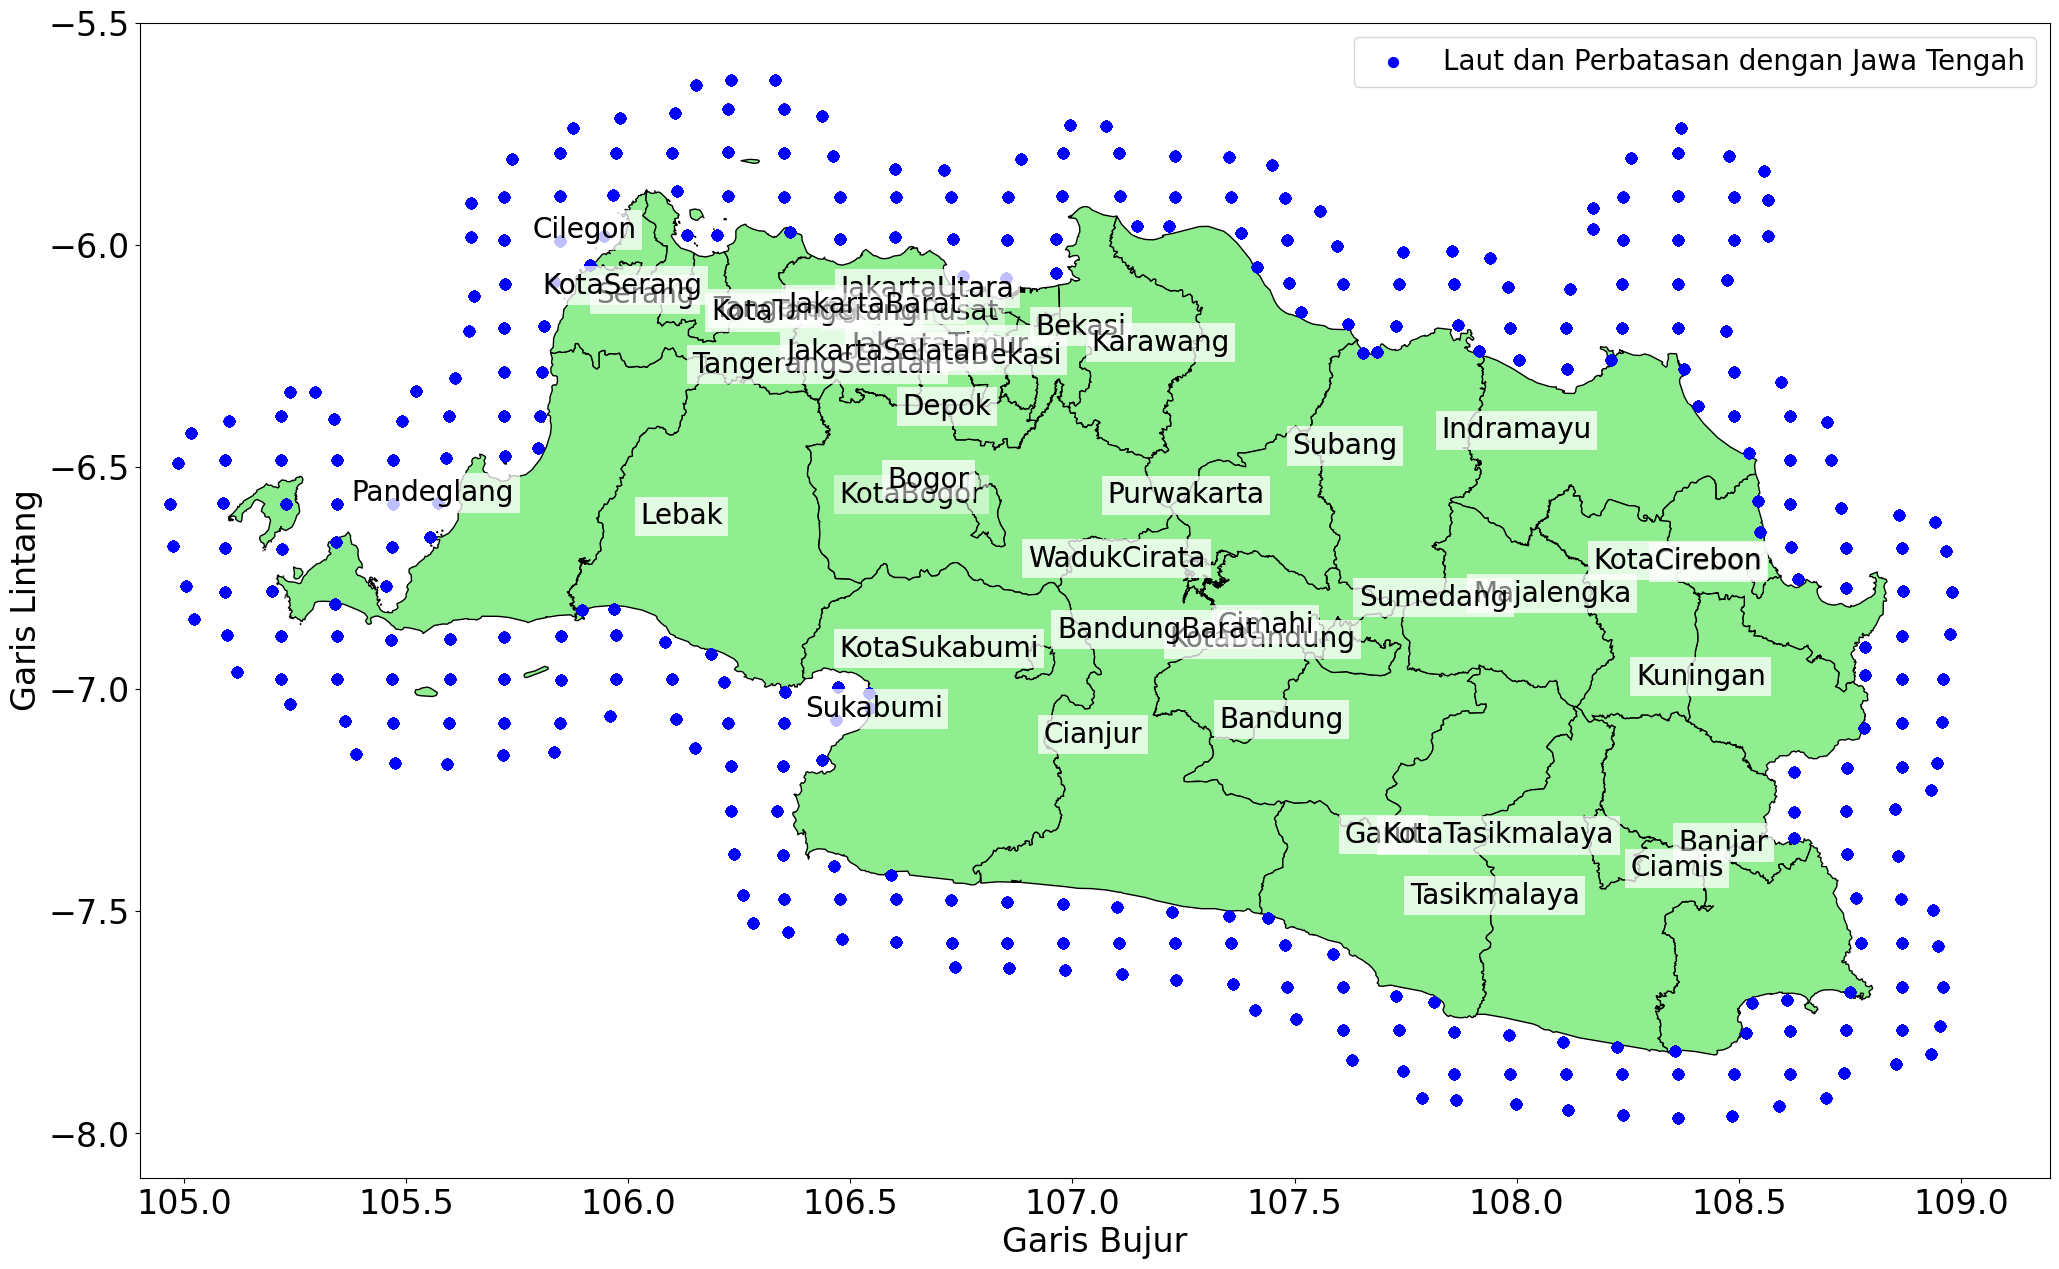

In [ ]:
# Filter only provinces in Jawa
jawa_provinces = df.city.unique()
jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]

# Plot Jawa map
fig, ax = plt.subplots(figsize=(25, 15))
jawa.plot(ax=ax, color='lightgreen', edgecolor='black')

# City points (excluding "Sea") and remove duplicate coordinates
cities = gdf[gdf['city'] != 'Sea']
cities_unique = cities.drop_duplicates(subset=['x_coord', 'y_coord'])
# cities_unique.plot(ax=ax, color='red', markersize=0, label='Kota')

# Sea points (if any), can still be displayed if desired
sea = gdf[gdf['city'] == 'Sea']
if not sea.empty:
    sea.plot(ax=ax, color='blue', markersize=50, label='Laut dan Perbatasan dengan Jawa Tengah')

# Add city labels only for unique points
for x, y, label in zip(cities_unique['x_coord'], cities_unique['y_coord'], cities_unique['city']):
    ax.text(x, y, label, fontsize=20, ha='right', va='bottom',
            bbox=dict(facecolor="white", alpha=0.5, edgecolor='none'))

# Add title and legend
# plt.title('Titik Koordinat Unik Kota', fontsize=30)
plt.legend(fontsize=20)

# Set font size for x and y axis labels
ax.set_xlabel('Garis Bujur', fontsize=24)
ax.set_ylabel('Garis Lintang', fontsize=24)

# Set font size for x and y axis tick labels
ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)


# Set Jawa region limits
ax.set_xlim(104.9, 109.2)
ax.set_ylim(-8.1, -5.5)

plt.show()

In [22]:

#Convert to Numerical Value
df['time'] = (df['date'] - df['date'].min()).dt.days

scale = 1e-5
df.NO2_mean = df.NO2_mean/scale


In [23]:
df

,x_coord,y_coord,date,NO2_mean,city,time
4795,106.166337,-6.123216,2023-05-01,3.938850,KotaSerang,0
4798,107.414924,-6.897186,2023-05-01,2.572816,BandungBarat,0
4800,106.651931,-6.182884,2023-05-01,9.192358,KotaTangerang,0
4801,107.788766,-7.359739,2023-05-01,2.612244,Garut,0
4802,108.466208,-7.434468,2023-05-01,5.625617,Ciamis,0
...,...,...,...,...,...,...
172285,108.959799,-6.977997,2025-04-29,1.694724,Sea,729
172279,108.960063,-7.670531,2025-04-29,1.329156,Sea,729
172288,108.967292,-6.688445,2025-04-29,1.914681,Sea,729
172286,108.974448,-6.876551,2025-04-29,2.544793,Sea,729


In [24]:
df.describe()

,x_coord,y_coord,date,NO2_mean,time
count,191728.000000,191728.000000,191728,191728.000000,191728.000000
mean,107.101734,-6.739350,2024-03-31 22:12:49.389969408,2.726761,335.925572
min,104.968469,-7.964794,2023-05-01 00:00:00,0.000203,0.000000
25%,106.082504,-7.370404,2023-09-29 00:00:00,1.273526,151.000000
50%,107.101275,-6.681646,2024-04-05 00:00:00,1.917604,340.000000
75%,108.240269,-6.094171,2024-09-11 00:00:00,2.967739,499.000000
max,108.980321,-5.627853,2025-04-29 00:00:00,78.734593,729.000000
std,1.209680,0.680955,NaN,3.009163,205.982048


In [ ]:
filtered_list = []

full_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(),freq='D')
df2 = (df.set_index('date').groupby(['city', 'x_coord', 'y_coord']).apply(lambda g: g.reindex(full_dates)).reset_index(level=[0, 1, 2]).rename_axis('date').reset_index())
df2['NO2_mean'] = (df2.groupby(['city', 'x_coord', 'y_coord'])['NO2_mean'].apply(lambda s: s.interpolate(method='linear', limit_direction='both')))

np.random.seed(42)
for city, subdf in df.groupby('city'):
    if city == 'Sea':
        # Filter per (x_coords, y_coords) within 'Sea'
        for (x, y), subsubdf in subdf.groupby(['x_coord', 'y_coord']):
            signal = subsubdf['NO2_mean'].values
            n = len(signal)

            # Low-pass filter
            fft_vals = np.fft.fft(signal)
            freqs = np.fft.fftfreq(n, d=1)
            cutoff = 0.1
            mask = np.abs(freqs) < cutoff
            filtered_fft = fft_vals * mask
            filtered_signal = np.fft.ifft(filtered_fft).real

            subsubdf = subsubdf.copy()
            subsubdf['NO2_filtered'] = filtered_signal
            filtered_list.append(subsubdf)
    else:
        # Process non-Sea cities as usual
        signal = subdf['NO2_mean'].values
        n = len(signal)

        fft_vals = np.fft.fft(signal)  # magnitude and phase (angle) (V(s))
        freqs = np.fft.fftfreq(n, d=1)  # frequency of the i-th component (s)
        cutoff = 0.1
        mask = np.abs(freqs) < cutoff #H(s)
        filtered_fft = fft_vals * mask #W(s) = H(s)* V(s)
        filtered_signal = np.fft.ifft(filtered_fft).real

        subdf = subdf.copy()
        subdf['NO2_filtered'] = filtered_signal
        filtered_list.append(subdf)

# Combine all back
filtered_df = pd.concat(filtered_list)
filtered_df = df.merge(
    filtered_df[['date', 'city', 'x_coord', 'y_coord', 'NO2_filtered']],
    on=['date', 'city', 'x_coord', 'y_coord'],
    how='left'
)

In [ ]:
from matplotlib.ticker import FuncFormatter

# Formatter untuk sumbu-y dalam bentuk 10^-2
def format_y(val, pos):
    return f"{val:.1f}"

cities = filtered_df['city'].unique()

for city in cities:
    city_df = filtered_df[filtered_df['city'] == city]

    plt.figure(figsize=(12, 4))
    plt.plot(city_df['date'], city_df['NO2_mean'], label='Data Asli', alpha=0.6)
    plt.plot(city_df['date'], city_df['NO2_filtered'], label=r'Data Hasil $\it{Filtering}$', linewidth=2)
    plt.plot(city_df['date'], city_df['NO2_mean']-city_df['NO2_filtered'], label = 'Residu $\it{Filtering}$', color='black', alpha=0.3)

    plt.title(f'Tren Konsentrasi NO₂ – {city}')
    plt.xlabel('Waktu $(t)$')
    plt.ylabel('Konsentrasi NO₂\n$(10^{-5})$ mol/m²')  # Gunakan LaTeX untuk eksponen

    # Terapkan formatter ke sumbu-y
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y))

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
location_groups = filtered_df.groupby(['x_coord', 'y_coord'])
location_groups

In [26]:
from scipy.stats import kstest, norm
import pandas as pd

# Create an empty list to store the results
results_list = []

print("Performing Kolmogorov-Smirnov Test for Normality of Filtering Residuals:")

# Iterate through unique cities
for city, city_df in filtered_df.groupby('city'):
    if city == 'Sea':
        # For 'Sea' locations, group by x_coord and y_coord
        for (x, y), location_df in city_df.groupby(['x_coord', 'y_coord']):
            residuals = location_df['NO2_mean'] - location_df['NO2_filtered']

            # Removed the check for len(residuals) >= 3

            mean_residuals = residuals.mean()
            std_residuals = residuals.std()

            if std_residuals > 0: # Avoid division by zero if all residuals are the same
                stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))
                normality = "Gaussian" if p > 0.01 else "Not Gaussian"
                results_list.append({
                    'City': city,
                    'x_coord': x,
                    'y_coord': y,
                    'Test Statistic (KS)': stat,
                    'P-value (KS)': p,
                    'Normality (KS)': normality,
                    'Data Points': len(residuals)
                })
            else:
                 results_list.append({
                    'City': city,
                    'x_coord': x,
                    'y_coord': y,
                    'Test Statistic (KS)': None,
                    'P-value (KS)': None,
                    'Normality (KS)': "Standard deviation is zero",
                    'Data Points': len(residuals)
                })
    else:
        # For other cities, perform test on all residuals for that city
        residuals = city_df['NO2_mean'] - city_df['NO2_filtered']

        # Removed the check for len(residuals) >= 3

        mean_residuals = residuals.mean()
        std_residuals = residuals.std()

        if std_residuals > 0:
            stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))
            normality = "Gaussian" if p > 0.01 else "Not Gaussian"
            results_list.append({
                'City': city,
                'x_coord': None, # Set to None as it's city-wide
                'y_coord': None, # Set to None as it's city-wide
                'Test Statistic (KS)': stat,
                'P-value (KS)': p,
                'Normality (KS)': normality,
                'Data Points': len(residuals)
            })
        else:
            results_list.append({
                'City': city,
                'x_coord': None,
                'y_coord': None,
                'Test Statistic (KS)': None,
                'P-value (KS)': None,
                'Normality (KS)': "Standard deviation is zero",
                'Data Points': len(residuals)
            })


# Create a DataFrame from the results list
normality_results_df = pd.DataFrame(results_list)

# Display the DataFrame, sorting by city for better readability
display(normality_results_df.sort_values(by='City'))

Performing Kolmogorov-Smirnov Test for Normality of Filtering Residuals:


,City,x_coord,y_coord,Test Statistic (KS),P-value (KS),Normality (KS),Data Points
0,Bandung,NaN,NaN,0.058732,0.069088,Gaussian,482
1,BandungBarat,NaN,NaN,0.046902,0.212662,Gaussian,502
2,Banjar,NaN,NaN,0.053999,0.175404,Gaussian,411
3,Bekasi,NaN,NaN,0.060084,0.029116,Gaussian,580
4,Bogor,NaN,NaN,0.045351,0.231011,Gaussian,517
...,...,...,...,...,...,...,...
363,Sumedang,NaN,NaN,0.069295,0.011610,Gaussian,531
364,Tangerang,NaN,NaN,0.055769,0.064080,Gaussian,547
365,TangerangSelatan,NaN,NaN,0.111499,0.000389,Not Gaussian,340
366,Tasikmalaya,NaN,NaN,0.057738,0.040741,Gaussian,578


In [ ]:
normality_results_df[(normality_results_df.City != "Sea")].reset_index(drop=True)

,City,x_coord,y_coord,Test Statistic (KS),P-value (KS),Normality (KS),Data Points
0,Bandung,NaN,NaN,0.058732,0.069088,Gaussian,482
1,BandungBarat,NaN,NaN,0.046902,0.212662,Gaussian,502
2,Banjar,NaN,NaN,0.053999,0.175404,Gaussian,411
3,Bekasi,NaN,NaN,0.060084,0.029116,Gaussian,580
4,Bogor,NaN,NaN,0.045351,0.231011,Gaussian,517
5,Ciamis,NaN,NaN,0.082095,0.000525,Not Gaussian,607
6,Cianjur,NaN,NaN,0.064387,0.014705,Gaussian,587
7,Cilegon,NaN,NaN,0.104694,0.000037,Not Gaussian,493
8,Cimahi,NaN,NaN,0.043723,0.605412,Gaussian,297
9,Cirebon,NaN,NaN,0.042437,0.231811,Gaussian,590


In [27]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,230
Not Gaussian,138


In [28]:
filtered_df = filtered_df[filtered_df.NO2_filtered>=0]
filtered_df.describe()

,x_coord,y_coord,date,NO2_mean,time,NO2_filtered
count,191695.000000,191695.000000,191695,191695.000000,191695.000000,191695.000000
mean,107.101956,-6.739462,2024-03-31 21:57:31.977360128,2.726966,335.914953,2.727295
min,104.968469,-7.964794,2023-05-01 00:00:00,0.000203,0.000000,0.014137
25%,106.082504,-7.370404,2023-09-29 00:00:00,1.273537,151.000000,1.374342
50%,107.101275,-6.681646,2024-04-05 00:00:00,1.917703,340.000000,1.973526
75%,108.240269,-6.094171,2024-09-11 00:00:00,2.967950,499.000000,2.944250
max,108.980321,-5.627853,2025-04-29 00:00:00,78.734593,729.000000,35.611021
std,1.209662,0.680952,NaN,3.009368,205.986270,2.531330


In [29]:
np.random.seed(42)
shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

In [30]:
X_train

<tf.Tensor: shape=(134186, 3), dtype=float32, numpy=
array([[532.       , 105.118355 ,  -6.9626536],
       [422.       , 106.019356 ,  -5.998129 ],
       [710.       , 105.36356  ,  -7.0713553],
       ...,
       [338.       , 108.363235 ,  -7.867246 ],
       [666.       , 106.109924 ,  -5.8795695],
       [173.       , 107.299065 ,  -6.737873 ]], dtype=float32)>

In [31]:
u_train

<tf.Tensor: shape=(134186, 1), dtype=float32, numpy=
array([[ 1.3696043],
       [11.113276 ],
       [ 2.1920397],
       ...,
       [ 1.2950594],
       [ 5.3553967],
       [ 5.3786726]], dtype=float32)>

In [32]:
X_test

<tf.Tensor: shape=(57509, 3), dtype=float32, numpy=
array([[621.       , 106.224724 ,  -5.891141 ],
       [701.       , 108.56532  ,  -5.979962 ],
       [425.       , 108.56028  ,  -7.0042048],
       ...,
       [403.       , 107.98065  ,  -6.094171 ],
       [133.       , 108.363235 ,  -6.1876454],
       [ 80.       , 107.65512  ,  -6.244249 ]], dtype=float32)>

In [33]:
u_test

<tf.Tensor: shape=(57509, 1), dtype=float32, numpy=
array([[7.61967  ],
       [2.4532785],
       [1.9744536],
       ...,
       [1.7757777],
       [1.2669439],
       [2.9264426]], dtype=float32)>

# Persiapan Arsitektur PINN

In [34]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}
n_models = 5

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

#4. Constructing Loss Function

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t, u_xx, u_yy, model, u_data= u_train):
    pde_residual = scale*(u_t - model.lambd * (u_xx + u_yy))
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y,model):

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t - model.lambd * (u_xx + u_yy))
      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g


### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t, u_xx, u_yy, model,lambd,u_data)

def fun_r_fwd(t, x, y, u, u_t, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=1000):
    # PDE residual loss (unchanged)
    pde_residual =scale*(u_t - lambd * (u_xx + u_yy))
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Training Data and Evaluate Data

## PDP Model 1 Inverse

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5,1,1.5]
path = dir + "NO2Model/Fourier/Fourier_inv_swish/"

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =  0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =  0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

Streaming output truncated to the last 5000 lines.
Iteration 8841, Loss: 0.06174883991479874
Iteration 8842, Loss: 0.06175451725721359
Iteration 8843, Loss: 0.06178169324994087
Iteration 8844, Loss: 0.061825454235076904
Iteration 8845, Loss: 0.062086090445518494
Iteration 8846, Loss: 0.06285196542739868
Iteration 8847, Loss: 0.06439607590436935
Iteration 8848, Loss: 0.0653228834271431
Iteration 8849, Loss: 0.06529593467712402
Iteration 8850, Loss: 0.06354253739118576
Iteration 8851, Loss: 0.060966793447732925
Iteration 8852, Loss: 0.05948503315448761
Iteration 8853, Loss: 0.0599450059235096
Iteration 8854, Loss: 0.06163626164197922
Iteration 8855, Loss: 0.06325562298297882
Iteration 8856, Loss: 0.06405740976333618
Iteration 8857, Loss: 0.0635460689663887
Iteration 8858, Loss: 0.06232793256640434
Iteration 8859, Loss: 0.06054766848683357
Iteration 8860, Loss: 0.05911322683095932
Iteration 8861, Loss: 0.0584024153649807
Iteration 8862, Loss: 0.058812547475099564
Iteration 8863, Loss: 0.0

In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
hists_Adam1 = [None] * n_models

for i in range(n_models):
    hists_Adam1[i] = []

    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

### Loss Graph

len Atempt-0 and init lambda 0.5:  15114
len Atempt-0 and init lambda 1:  15160
len Atempt-0 and init lambda 1.5:  15215
\\
len Atempt-1 and init lambda 0.5:  15140
len Atempt-1 and init lambda 1:  15247
len Atempt-1 and init lambda 1.5:  15162
\\
len Atempt-2 and init lambda 0.5:  15182
len Atempt-2 and init lambda 1:  15193
len Atempt-2 and init lambda 1.5:  15249
\\
len Atempt-3 and init lambda 0.5:  15131
len Atempt-3 and init lambda 1:  15244
len Atempt-3 and init lambda 1.5:  15167
\\
len Atempt-4 and init lambda 0.5:  14674
len Atempt-4 and init lambda 1:  15186
len Atempt-4 and init lambda 1.5:  15164
\\


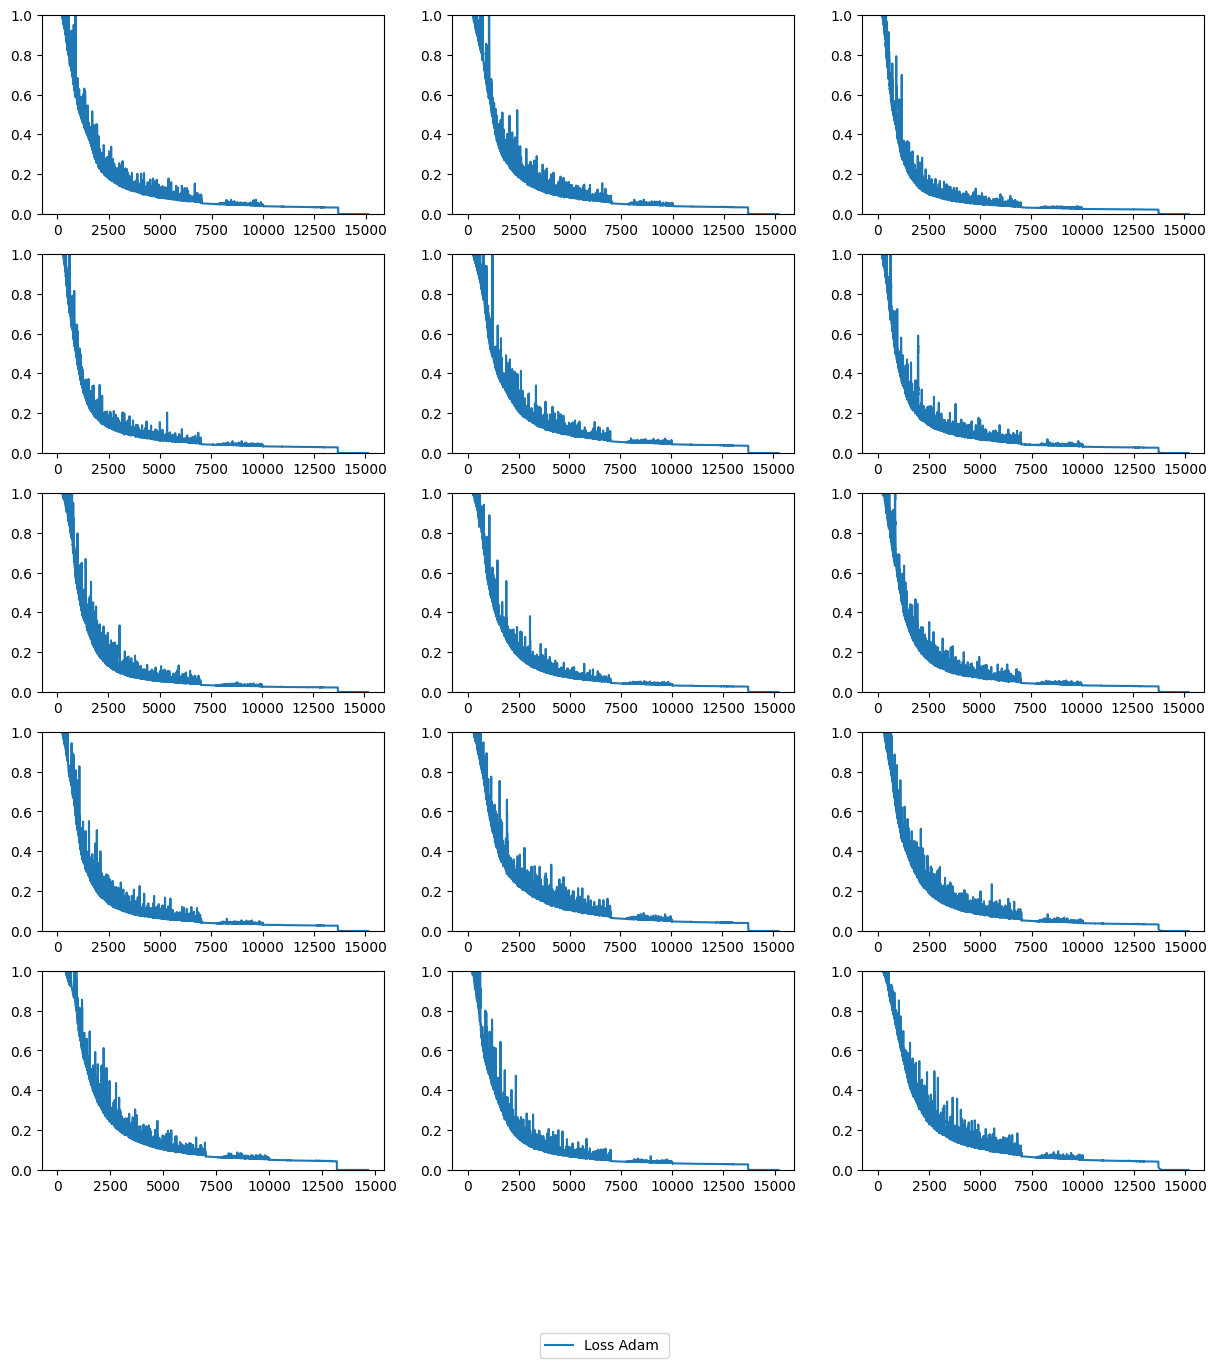

In [ ]:
# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,15))

for i in range(n_models):
  axes[i,0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i,0].set_ylim([0,1])

  axes[i,1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  axes[i,1].set_ylim([0,1])

  axes[i,2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  axes[i,2].set_ylim([0,1])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,1])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,1])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,1])


  print(f"len Atempt-{i} and init lambda {initial_lambdas[0]}: ",len(hists_Adam1[i][0].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[1]}: ",len(hists_Adam1[i][1].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[2]}: ",len(hists_Adam1[i][2].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[3]}: ",len(hists_Adam1[i][3].transpose()))

  print("\\\\")

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return hists[iter_model][iter_init][0][-1]

df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,0.00001,0.00001,0.00001
Attempt 2,0.00001,0.00001,0.00001
Attempt 3,0.00001,0.00001,0.00001
Attempt 4,0.00001,0.00001,0.00001
Attempt 5,0.00001,0.00001,0.00001


In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam_0.5    0.00001
Adam_1      0.00001
Adam_1.5    0.00001
dtype: float32
         Adam_0.5   Adam_1  Adam_1.5
Average   0.00001  0.00001   0.00001
StdDev    0.00000  0.00000   0.00000
CV        0.00000  0.00000   0.00000


## PDP Model 1 Forward

In [ ]:
n_models = 5
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

In [ ]:
path = dir + "NO2Model/Fourier/Fourier_fwd_swish/"

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

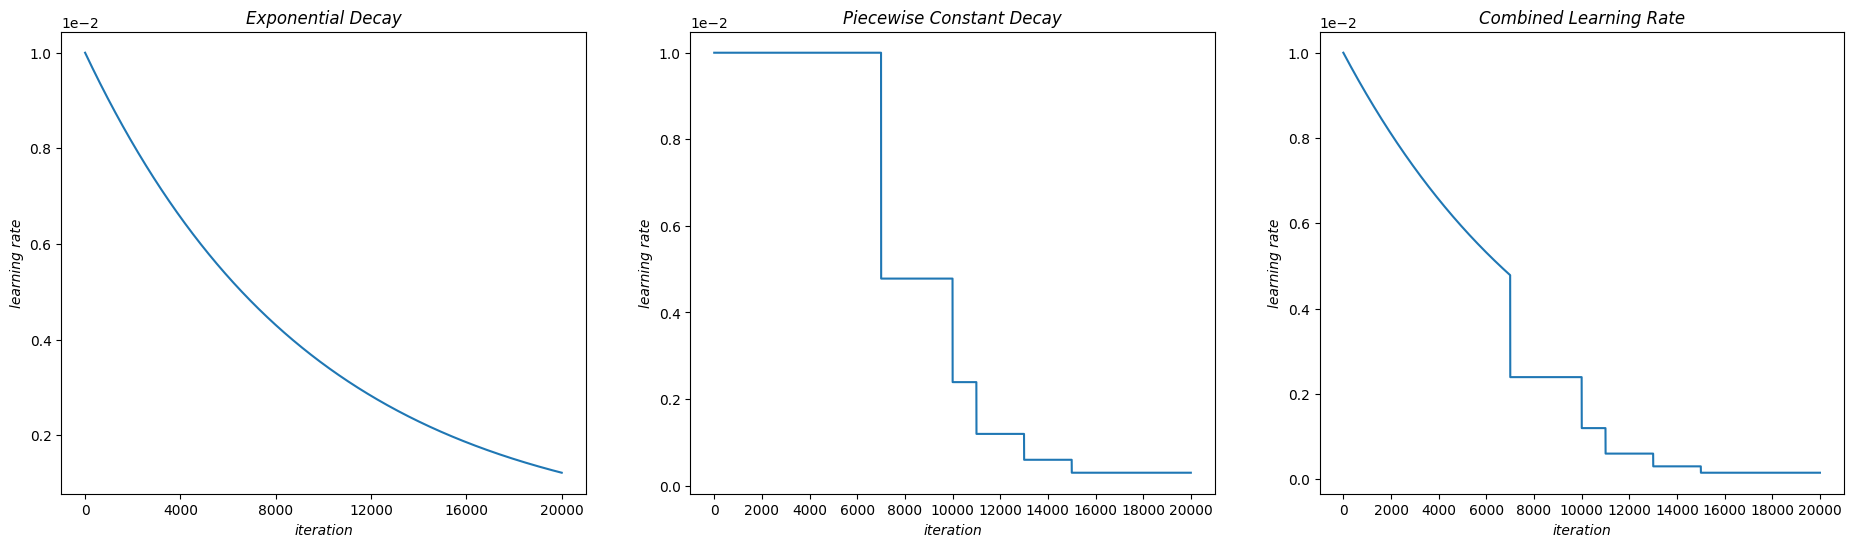

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [ ]:
pred_lambda = list(df.loc['Average'])

In [ ]:
pred_lambda

[9.999999747378752e-06, 9.999999747378752e-06, 9.999999747378752e-06]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models


for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, timeout=timeout)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

### Loss Function

len Atempt-0 Lambda ke- 0:  8577
len Atempt-0 Lambda ke- 1:  8591
len Atempt-0 Lambda ke- 2:  8595
\\
len Atempt-1 Lambda ke- 0:  8589
len Atempt-1 Lambda ke- 1:  8596
len Atempt-1 Lambda ke- 2:  8570
\\
len Atempt-2 Lambda ke- 0:  8589
len Atempt-2 Lambda ke- 1:  8595
len Atempt-2 Lambda ke- 2:  8585
\\
len Atempt-3 Lambda ke- 0:  8592
len Atempt-3 Lambda ke- 1:  8588
len Atempt-3 Lambda ke- 2:  8574
\\
len Atempt-4 Lambda ke- 0:  8584
len Atempt-4 Lambda ke- 1:  8565
len Atempt-4 Lambda ke- 2:  8565
\\


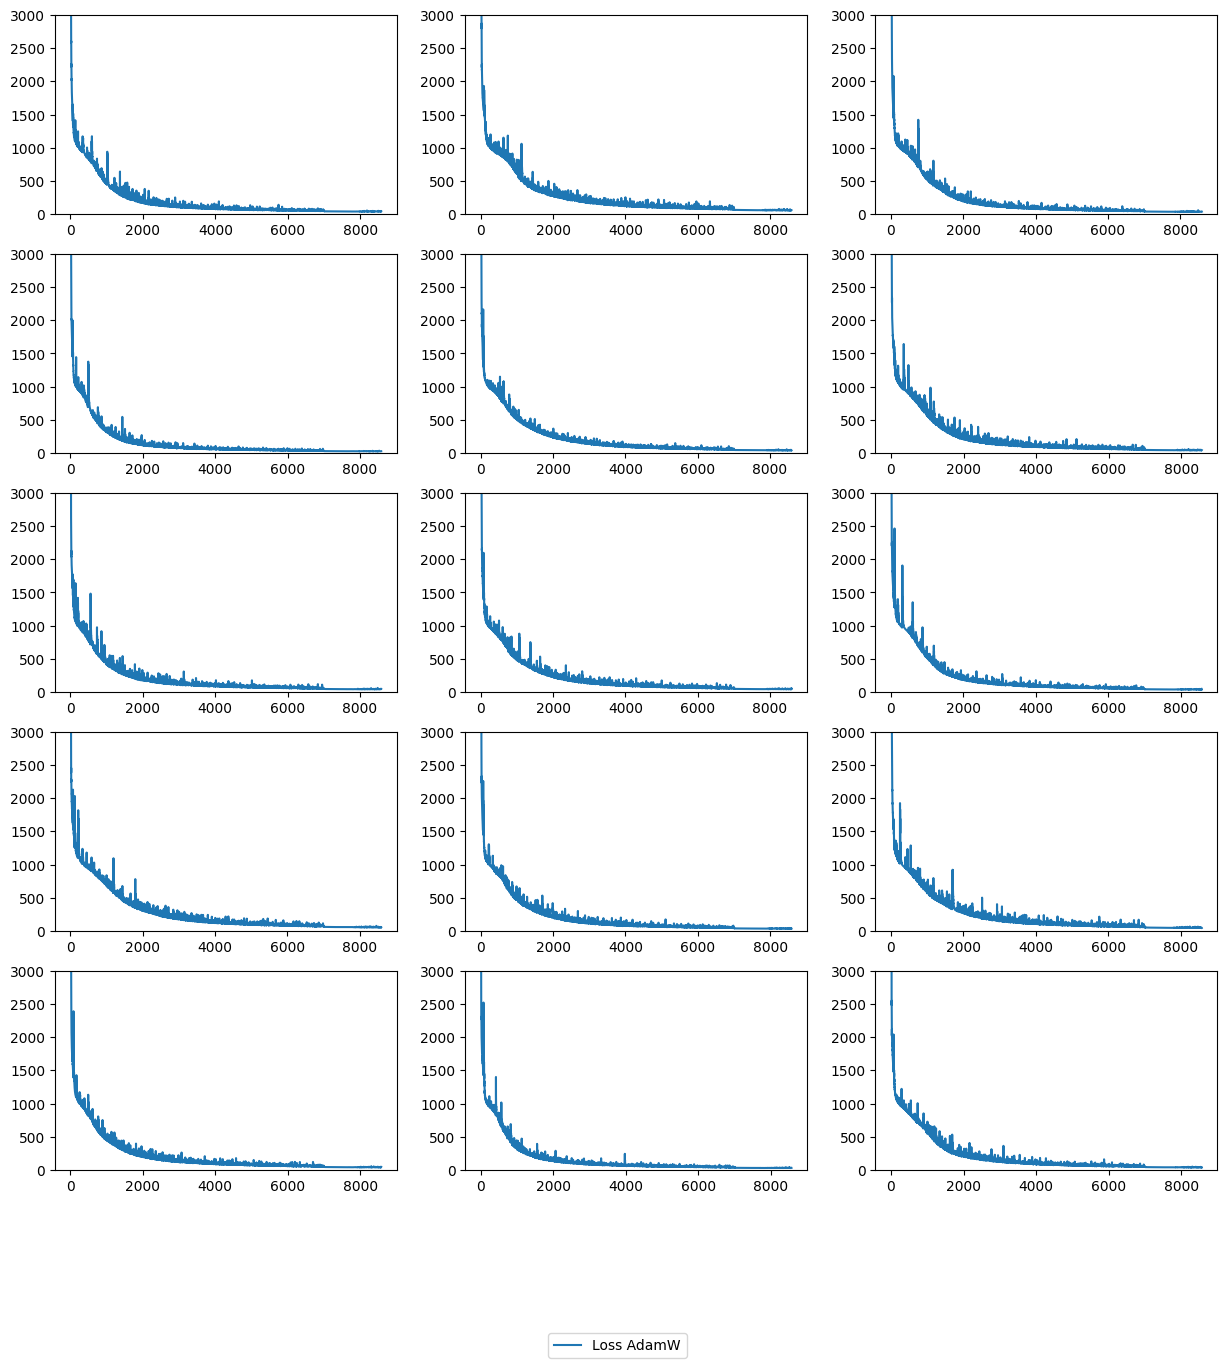

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(15,15))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i,j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i,j].set_ylim([0,3e3])
  # # for j in range(len(pred_lambda)):
  #   axes[i][j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[i][j].set_ylim([0,1e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))

df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])
initial_lambdas = [0.5,1,1.5]

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,"(0.15254706, 8.272432)","(0.17867658, 9.2346)","(0.14271985, 7.6422067)"
Attempt 2,"(0.12283377, 6.4503007)","(0.15048315, 8.0392)","(0.15910685, 8.120554)"
Attempt 3,"(0.1606299, 8.712317)","(0.15753745, 8.22273)","(0.1476914, 7.935838)"
Attempt 4,"(0.17477228, 9.298735)","(0.141546, 7.561194)","(0.15759222, 8.413209)"
Attempt 5,"(0.16165936, 8.224095)","(0.12935297, 7.0292244)","(0.14399529, 7.9488964)"


In [ ]:
preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,"(0.20599985, 10.331138)","(0.2301448, 11.2485695)","(0.1962353, 9.70215)"
Attempt 2,"(0.1760215, 8.569541)","(0.20487396, 10.160113)","(0.21201317, 10.165138)"
Attempt 3,"(0.20987354, 10.575099)","(0.20961045, 10.201563)","(0.2012647, 9.999747)"
Attempt 4,"(0.22619188, 11.199092)","(0.19467723, 9.697641)","(0.2116697, 10.495954)"
Attempt 5,"(0.21445553, 10.259041)","(0.18272768, 9.094147)","(0.19950743, 10.075707)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

          mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam_0.5  0.206508  0.018652  0.090322  10.186782  0.976869  0.095896
Adam_1    0.204407  0.017709  0.086634  10.080407  0.791337  0.078502
Adam_1.5  0.204138  0.007261  0.035570  10.087739  0.286878  0.028438


In [ ]:
import os

# Define the directory where you want to save the CSV files
output_dir = dir + "NO2Model/Fourier/predictions/swish" # Assuming 'dir' is defined

for i in range(n_models):
    for j in range(len(pred_lambda)):
        # Get the prediction for the current model and initial lambda
        current_pred = preds_Adam_comb[i * len(pred_lambda) + j].numpy()

        # Create a DataFrame from the prediction
        # You might want to include time, x, and y coordinates as well
        X_test_np = X_test.numpy()

        pred_df = pd.DataFrame({
            'time': X_test_np[:, 0],
            'x_coord': X_test_np[:, 1],
            'y_coord': X_test_np[:, 2],
            'predicted_NO2_mean': current_pred.flatten()
        })

        # Define the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Save the DataFrame to a CSV file
        pred_df.to_csv(filepath, index=False)

        print(f"Saved prediction to: {filepath}")

Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_1_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_1_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_1_lambda_3.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_2_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_2_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_2_lambda_3.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_3_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swish/prediction_model_3_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/swi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np # Make sure numpy is imported for np.round
import datetime as dt
output_dir = dir + "NO2Model/Fourier/predictions/swish/"

# Assuming X_test, u_test, and test_df are already loaded
# Convert X_test and u_test to numpy arrays for easier manipulation if they are not already
X_test_np = X_test.numpy() if isinstance(X_test, tf.Tensor) else X_test
u_test_np = u_test.numpy().flatten() if isinstance(u_test, tf.Tensor) else u_test.flatten()

# Ensure test_df is loaded and contains the 'city' column and 'date' column
# If not, load it or make sure it's available in your environment

# Extract city names and datetime objects from the original test_df
cities = test_df['city'].values
dates = test_df['date'].dt.date.values # Assuming 'date' column is already datetime


# n_models = 5
len_pred_lambda = 3 # Assuming the number of initial lambdas is 3

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len_pred_lambda):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_NO2_mean'].values
        })

        # Pivot to get heatmap data using 'date' and 'city'
        heatmap_data_test = df.pivot_table(
            index='date',
            columns='city',
            values='u_test',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        heatmap_data_pred = df.pivot_table(
            index='date',
            columns='city',
            values='u_pred',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        # Determine shared color scale limits from the true data
        vmin = np.min(heatmap_data_test.min().min()) if not heatmap_data_test.empty else None
        vmax = np.max(heatmap_data_test.max().max()) if not heatmap_data_test.empty else None

        # Create the heatmap plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))

        # Plot true values with shared color scale
        if not heatmap_data_test.empty:
            sns.heatmap(heatmap_data_test, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax1)
        ax1.set_title('True Values (u_test)')
        ax1.set_xlabel('City')
        ax1.set_ylabel('Date')

        # Plot predictions with shared color scale
        if not heatmap_data_pred.empty:
             sns.heatmap(heatmap_data_pred, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax2)
        ax2.set_title(f'Predictions (u_pred) - Model {i+1}, Lambda {j+1}') # Dynamic title
        ax2.set_xlabel('City')
        ax2.set_ylabel('Date')

        plt.tight_layout()
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len_pred_lambda):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df_recap = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_NO2_mean'].values
        })
        nrows = 10
        ncols= 5
        unique_cities = df_recap['city'].unique()
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = axes.flatten() # Flatten the axes array for easy indexing

        # Iterate through unique cities and plot on their respective subplots
        for city_idx, city in enumerate(unique_cities):
            city_df = df_recap[df_recap['city'] == city].copy()

            sns.lineplot(data=city_df, x='date', y='u_test', label='True', ax=axes[city_idx])
            sns.lineplot(data=city_df, x='date', y='u_pred', label='Predicted', ax=axes[city_idx])

            axes[city_idx].set_title(f'{city}')
            axes[city_idx].set_xlabel('Date')
            axes[city_idx].set_ylabel('NO2 Mean')
            axes[city_idx].tick_params(axis='x', rotation=45)
            axes[city_idx].grid(True)
            axes[city_idx].legend()

        # Hide any unused subplots if the number of cities is not a multiple of ncols
        for k in range(41, nrows * ncols):
            fig.delaxes(axes[k])

        fig.suptitle(f'NO2 Mean Over Time (Model-{i+1}, Lambda-{j+1})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
weights = models_Adam_comb[1][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 0.6165533  -0.69899184 -0.25158808 -2.846939   -0.4154463  -1.1471238
  -0.9936313   0.11665209  0.00473816 -1.6961745   0.4133505  -0.20835291
   2.5144126   0.06190308 -0.22771856  0.40520698  1.144984    0.49765295
  -0.4544754   1.2363149  -1.6542349  -1.1383154   0.98124695  0.71587443
   0.03049224 -0.14771473 -2.8585188   0.23045881  0.6589043   1.7622182
   3.2985022   1.6469219  -1.5122626   0.22302996  1.8693563   2.2426522
  -1.5732262   1.1261348  -0.81624126 -1.1152236   0.14563166  0.3722067
   0.40621218  0.04181186 -1.772573   -1.1724786  -0.16412258 -2.2545364
   1.8243628   0.6162915  -1.1533508   0.11679183  0.03517969 -1.1551766
   0.5510732  -0.03201467 -1.0154763   0.05658383  0.8727371  -2.022772
  -1.4679446  -1.640551   -0.33463275  0.01531365]
 [ 0.467932    1.2992486  -0.40683404 -2.1950114   0.60189116 -0.3618776
   0.5310549   0.5511158   0.6379184  -0.901147    0.11026067 -1.65953
   0.88655406 -1.9662175   1.9948854   0.935341

In [ ]:
weights2 = models_Adam_comb[4][1].get_weights()

for i, w in enumerate(weights2):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-0.22833937  0.3680546   0.4380382  -2.0636826  -1.8582196   0.48703045
   0.961743    0.5198904  -0.66223145  1.0900985   0.09921959  1.1117346
   1.3757089  -0.09833238  1.0784526  -0.00486065  0.36803886 -0.3707895
   1.4588493  -1.3315684   0.01940011  0.47092816 -1.2434951   1.2373574
  -1.4143437   1.0344489  -0.19000213  0.876812    0.57117385 -0.4861244
   2.8504167  -0.06205427  1.1787015  -0.8007725  -2.425968   -0.05254005
  -0.08999003 -2.568036   -0.548955   -1.5622325  -2.5443308  -0.8140453
  -0.68273157 -0.6264944  -0.33449218  0.5309402   0.25352225 -1.7127621
  -0.2460907  -0.31135044  0.60806745  0.09875076  1.9644129  -0.10756194
   0.538536   -1.3087116   1.8571507   1.592167    2.5291407   0.01847059
  -0.58283865  0.17427799  0.13436309  0.43275514]
 [-1.3213902   2.2706654   1.45056    -0.46067712 -1.0476228   1.1656917
   1.2074704   0.7624815   0.7037287  -1.6746521   0.3656735   0.9783467
   0.16657035  0.8488105   1.4202685  -0.99

In [ ]:
weights3 = models_Adam_comb[0][2].get_weights()

for i, w in enumerate(weights3):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 1.33598399e+00  1.25894230e-02 -1.18677817e-01 -6.71506941e-01
  -1.57139695e+00 -9.96560305e-02  1.96224248e+00 -7.07161009e-01
  -1.13914657e+00 -2.98931807e-01  1.71675456e+00  9.41177964e-01
  -9.35132895e-03  2.33515173e-01  1.52099526e+00 -8.50706875e-01
   2.39576006e+00  1.98971164e+00  6.30869925e-01 -7.43356228e-01
  -1.72951698e+00  1.24042726e+00 -4.75086480e-01  2.01574460e-01
   9.32017192e-02  1.21483183e+00  8.99420023e-01 -2.16129348e-01
   9.31921959e-01  6.52305305e-01 -1.14317906e+00  5.14192283e-01
   9.62480962e-01  7.82256842e-01  1.13930297e+00  8.39346468e-01
  -2.38986492e-01  2.41698083e-02  1.47312248e+00  1.10950649e+00
   8.82433131e-02 -4.33784902e-01  3.33117425e-01 -1.66040242e+00
   1.37582600e+00 -6.17221296e-01  1.58795714e+00 -6.07772231e-01
  -7.14645565e-01  3.80727708e-01 -8.62855852e-01 -4.48803067e-01
   3.34066935e-02  6.39575899e-01  1.98175108e+00  9.27969933e-01
   1.76798272e+00 -4.87962253e-02 -8.47837090e-01 

In [ ]:
path

'/content/drive/My Drive/TA/NO2Model/Fourier/Fourier_fwd_swish/'

In [ ]:
import tensorflow as tf
# from tensorflow.keras.models import load_model # Not needed for loading weights only

# Assuming 'arch' and 'lb', 'ub' are defined in previous cells
# Create the model with the correct architecture
demo = PINN_NeuralNet(lb=lb, ub=ub, **arch)
# Build the model (important before loading weights)
demo.build((None, 3))
_ = demo(tf.zeros((1, 3)))
# Load the weights into the model
demo.load_weights(path+'_1_model_Adam_comb_0.weights.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_26', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
demo.get_weights()

[array([[ 0.6165533 , -0.69899184, -0.25158808, -2.846939  , -0.4154463 ,
         -1.1471238 , -0.9936313 ,  0.11665209,  0.00473816, -1.6961745 ,
          0.4133505 , -0.20835291,  2.5144126 ,  0.06190308, -0.22771856,
          0.40520698,  1.144984  ,  0.49765295, -0.4544754 ,  1.2363149 ,
         -1.6542349 , -1.1383154 ,  0.98124695,  0.71587443,  0.03049224,
         -0.14771473, -2.8585188 ,  0.23045881,  0.6589043 ,  1.7622182 ,
          3.2985022 ,  1.6469219 , -1.5122626 ,  0.22302996,  1.8693563 ,
          2.2426522 , -1.5732262 ,  1.1261348 , -0.81624126, -1.1152236 ,
          0.14563166,  0.3722067 ,  0.40621218,  0.04181186, -1.772573  ,
         -1.1724786 , -0.16412258, -2.2545364 ,  1.8243628 ,  0.6162915 ,
         -1.1533508 ,  0.11679183,  0.03517969, -1.1551766 ,  0.5510732 ,
         -0.03201467, -1.0154763 ,  0.05658383,  0.8727371 , -2.022772  ,
         -1.4679446 , -1.640551  , -0.33463275,  0.01531365],
        [ 0.467932  ,  1.2992486 , -0.40683404, -2

In [ ]:
for i, w in enumerate(demo.get_weights()):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 0.6165533  -0.69899184 -0.25158808 -2.846939   -0.4154463  -1.1471238
  -0.9936313   0.11665209  0.00473816 -1.6961745   0.4133505  -0.20835291
   2.5144126   0.06190308 -0.22771856  0.40520698  1.144984    0.49765295
  -0.4544754   1.2363149  -1.6542349  -1.1383154   0.98124695  0.71587443
   0.03049224 -0.14771473 -2.8585188   0.23045881  0.6589043   1.7622182
   3.2985022   1.6469219  -1.5122626   0.22302996  1.8693563   2.2426522
  -1.5732262   1.1261348  -0.81624126 -1.1152236   0.14563166  0.3722067
   0.40621218  0.04181186 -1.772573   -1.1724786  -0.16412258 -2.2545364
   1.8243628   0.6162915  -1.1533508   0.11679183  0.03517969 -1.1551766
   0.5510732  -0.03201467 -1.0154763   0.05658383  0.8727371  -2.022772
  -1.4679446  -1.640551   -0.33463275  0.01531365]
 [ 0.467932    1.2992486  -0.40683404 -2.1950114   0.60189116 -0.3618776
   0.5310549   0.5511158   0.6379184  -0.901147    0.11026067 -1.65953
   0.88655406 -1.9662175   1.9948854   0.935341

# Reconstruction or Imputation

In [35]:
import tensorflow as tf
import os

# Assuming 'arch' and 'lb', 'ub' are defined in previous cells
# Assuming 'n_models' and 'pred_lambda' are defined
n_models=5
# Create the models with the correct architecture
pred_lambda = [0.5]
models_Adam_comb = [[None for _ in range(len(pred_lambda))] for _ in range(n_models)]

# Load the weights into the specified model
i = 1
j = 0
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

path = dir + 'NO2Model/Fourier/Fourier_fwd_swish/'

# Create the model instance
models_Adam_comb[i][j] = PINN_NeuralNet(lb=lb, ub=ub, **arch)

# Build the model (important before loading weights)
models_Adam_comb[i][j].build((None, 3))
# A dummy forward pass is sometimes needed to fully build the model before loading weights
_ = models_Adam_comb[i][j](tf.zeros((1, 3)))

# Construct the filename
filename = f"_{i}_model_Adam_comb_{j}.weights.h5"
filepath = os.path.join(path, filename)

# Load the weights into the model
try:
    models_Adam_comb[i][j].load_weights(filepath)
    print(f"Loaded weights for model {i+1}, lambda {j+1} from: {filepath}")
except FileNotFoundError:
    print(f"Error: Weight file not found at {filepath}. Skipping.")
except Exception as e:
    print(f"An error occurred while loading weights from {filepath}: {e}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Loaded weights for model 2, lambda 1 from: /content/drive/My Drive/TA/NO2Model/Fourier/Fourier_fwd_swish/_1_model_Adam_comb_0.weights.h5


In [44]:
models_Adam_comb[1][0].get_weights()

[array([[ 0.6165533 , -0.69899184, -0.25158808, -2.846939  , -0.4154463 ,
         -1.1471238 , -0.9936313 ,  0.11665209,  0.00473816, -1.6961745 ,
          0.4133505 , -0.20835291,  2.5144126 ,  0.06190308, -0.22771856,
          0.40520698,  1.144984  ,  0.49765295, -0.4544754 ,  1.2363149 ,
         -1.6542349 , -1.1383154 ,  0.98124695,  0.71587443,  0.03049224,
         -0.14771473, -2.8585188 ,  0.23045881,  0.6589043 ,  1.7622182 ,
          3.2985022 ,  1.6469219 , -1.5122626 ,  0.22302996,  1.8693563 ,
          2.2426522 , -1.5732262 ,  1.1261348 , -0.81624126, -1.1152236 ,
          0.14563166,  0.3722067 ,  0.40621218,  0.04181186, -1.772573  ,
         -1.1724786 , -0.16412258, -2.2545364 ,  1.8243628 ,  0.6162915 ,
         -1.1533508 ,  0.11679183,  0.03517969, -1.1551766 ,  0.5510732 ,
         -0.03201467, -1.0154763 ,  0.05658383,  0.8727371 , -2.022772  ,
         -1.4679446 , -1.640551  , -0.33463275,  0.01531365],
        [ 0.467932  ,  1.2992486 , -0.40683404, -2

In [36]:
import numpy as np
import pandas as pd
import math
import os
from google.colab import files
from concurrent.futures import ThreadPoolExecutor

# --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# Misal Anda sudah memiliki filtered_df
# Jika belum, upload:
# uploaded = files.upload()
# filtered_df = pd.read_csv("filtered_df.csv")

step = 1e-2  # Resolusi

t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


In [37]:
len(t_points)

730

In [38]:
len(x_points)

403

In [39]:
len(y_points)

235

In [40]:
len(t_points)*len(x_points)*len(y_points)

69134650

In [50]:
# --- 2. Pilih model dan path hasil ---
target_indices = [(1, 0)]  # sesuaikan
models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
model_labels   = [f"m{i}_{j}" for i, j in target_indices]
file_paths     = [f"/content/prediction_{label}.csv" for label in model_labels]

# --- 3. Buat file output kosong dengan header ---
for path in file_paths:
    if os.path.exists(path):
        os.remove(path)
    with open(path, "w") as f:
        f.write("t,x,y,prediction\n")

# --- 4. Precompute spatial meshgrid (xy pairs) sekali saja ---
xy_pairs = np.stack(np.meshgrid(x_points, y_points, indexing="ij"), -1).reshape(-1, 2)

# --- 5. Fungsi batch generator ---
def gen_batches(t_vec, batch_size=1_000_000):
    for t in t_vec:
        t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
        tx_y = np.hstack([t_col, xy_pairs])
        n_rows = tx_y.shape[0]
        n_batch = math.ceil(n_rows / batch_size)
        for k in range(n_batch):
            yield t, tx_y[k * batch_size : (k + 1) * batch_size]

# --- 6. Fungsi prediksi + tulis ke file ---
def predict_and_write(model, batch, path):
    pred = model.predict_on_batch(batch).reshape(-1, 1)
    output = np.hstack([batch, pred])
    df = pd.DataFrame(output, columns=["t", "x", "y", "prediction"])
    df.to_csv(path, mode="a", header=False, index=False, float_format="%.6g")

# --- 7. Loop utama: batch per waktu + paralel tulis model ---
for t_val, batch in gen_batches(t_points):
    print(f"Processing time: {t_val}, Batch shape: {batch.shape}")
    with ThreadPoolExecutor() as executor:
        for model, path in zip(models_to_use, file_paths):
            executor.submit(predict_and_write, model, batch, path)

Processing time: 0.0, Batch shape: (94705, 3)
Processing time: 1.0, Batch shape: (94705, 3)
Processing time: 2.0, Batch shape: (94705, 3)
Processing time: 3.0, Batch shape: (94705, 3)
Processing time: 4.0, Batch shape: (94705, 3)
Processing time: 5.0, Batch shape: (94705, 3)
Processing time: 6.0, Batch shape: (94705, 3)
Processing time: 7.0, Batch shape: (94705, 3)
Processing time: 8.0, Batch shape: (94705, 3)
Processing time: 9.0, Batch shape: (94705, 3)
Processing time: 10.0, Batch shape: (94705, 3)
Processing time: 11.0, Batch shape: (94705, 3)
Processing time: 12.0, Batch shape: (94705, 3)
Processing time: 13.0, Batch shape: (94705, 3)
Processing time: 14.0, Batch shape: (94705, 3)
Processing time: 15.0, Batch shape: (94705, 3)
Processing time: 16.0, Batch shape: (94705, 3)
Processing time: 17.0, Batch shape: (94705, 3)
Processing time: 18.0, Batch shape: (94705, 3)
Processing time: 19.0, Batch shape: (94705, 3)
Processing time: 20.0, Batch shape: (94705, 3)
Processing time: 21.0, 

KeyboardInterrupt: 

In [41]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

prediction_df = pd.read_csv("/content/drive/MyDrive/TA/Reconstruction/SeluruhWilayah_NO2_M3_Swish.csv")
prediction_cleaned_df =prediction_df.copy()
# Replace negative values in the 'prediction' column with 9
prediction_cleaned_df['prediction'] = prediction_df['prediction'].apply(lambda x: 0 if x < 0 else x)

In [42]:
prediction_df

,t,x,y,prediction
0,0,104.968,-7.96479,-1.031570
1,0,104.968,-7.95479,-0.877534
2,0,104.968,-7.94479,-0.735265
3,0,104.968,-7.93479,-0.636032
4,0,104.968,-7.92479,-0.599158
...,...,...,...,...
69134645,729,108.989,-5.66474,2.748040
69134646,729,108.989,-5.65474,2.692580
69134647,729,108.989,-5.64474,2.576090
69134648,729,108.989,-5.63474,2.409850


In [43]:
prediction_df.describe()

,t,x,y,prediction
count,6.913465e+07,6.913465e+07,6.913465e+07,6.913465e+07
mean,3.645000e+02,1.069790e+02,-6.794767e+00,2.328346e+00
std,2.107327e+02,1.163423e+00,6.783959e-01,2.581700e+00
min,0.000000e+00,1.049680e+02,-7.964790e+00,-4.404020e+01
25%,1.820000e+02,1.059690e+02,-7.384780e+00,1.214940e+00
50%,3.645000e+02,1.069790e+02,-6.794770e+00,1.852930e+00
75%,5.470000e+02,1.079890e+02,-6.204750e+00,2.928650e+00
max,7.290000e+02,1.089890e+02,-5.624740e+00,3.636500e+01


In [44]:
from datetime import datetime, timedelta

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
# Example: input day, month, year
target_day = 1
target_month = 10
target_year = 2024

# --- Step 3: Create the target date object ---
target_date = datetime(target_year, target_month, target_day)

# --- Step 4: Compute the number of days since start_date ---
t = (target_date - start_date).days

# --- Step 5: Print the result ---
print("t =", t)


t = 519


Filtered prediction data for time = 519. Shape: (94705, 4)


,t,x,y,prediction
49151895,519,104.968,-7.96479,1.43767
49151896,519,104.968,-7.95479,1.60495
49151897,519,104.968,-7.94479,1.72146
49151898,519,104.968,-7.93479,1.72494
49151899,519,104.968,-7.92479,1.67501



Merged GeoDataFrame:


/tmp/ipython-input-3172819289.py:29: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")


,t,x,y,prediction,geometry,index_right,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
49155555,519,105.118,-6.61476,1.70008,POINT (105.118 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155556,519,105.118,-6.60476,1.70783,POINT (105.118 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155790,519,105.129,-6.61476,1.74060,POINT (105.129 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155791,519,105.129,-6.60476,1.74912,POINT (105.129 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155792,519,105.129,-6.59476,1.75476,POINT (105.129 -6.59476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA


/tmp/ipython-input-3172819289.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


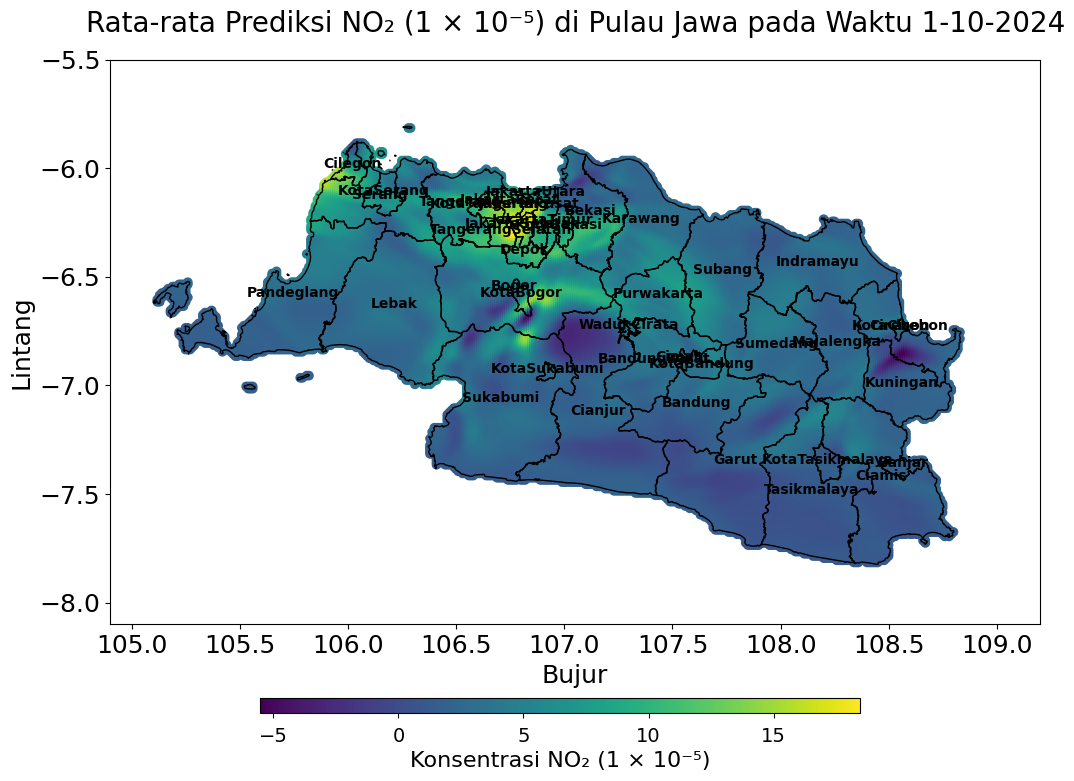

In [86]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- 2. Filter Data by Time ---
# Choose a specific time 't' to visualize
time_to_visualize = t  # Example: Visualize predictions at time step 365

filtered_prediction_df = prediction_df[prediction_df['t'] == time_to_visualize].copy()
if filtered_prediction_df.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {filtered_prediction_df.shape}")
    display(filtered_prediction_df.head())

    # --- 3. Prepare Geographical Data ---
    indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

    jawa_provinces = df.city.unique()
    jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]

    # --- 4. Merge Data ---
    geometry = [Point(xy) for xy in zip(filtered_prediction_df['x'], filtered_prediction_df['y'])]
    prediction_gdf = gpd.GeoDataFrame(filtered_prediction_df, geometry=geometry)

    merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())

    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(figsize=(12,7.5))

    # Plot Java map
    jawa.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot predicted NO₂
    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, cmap='viridis')

    # --- Draw boundaries and add labels ---
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)
    jawa['centroid'] = jawa.geometry.centroid

    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=10,
            color='black',
            weight='bold'
        )

    # --- Colorbar ---
    cax = fig.add_axes([0.25, 0, 0.5, 0.02])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=merged_gdf['prediction'].min(),
                           vmax=merged_gdf['prediction'].max())
    )
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Konsentrasi NO₂ (1 × 10⁻⁵)', fontsize=16)
    cbar.ax.tick_params(labelsize=14,pad=6)

    # --- Titles and labels ---
    ax.set_title(
        f'Rata-rata Prediksi NO₂ (1 × 10⁻⁵) di Pulau Jawa pada Waktu {target_day}-{target_month}-{target_year}',
        fontsize=20, pad=20
    )
    ax.set_xlabel('Bujur', fontsize=18)
    ax.set_ylabel('Lintang', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

    # --- Region limits ---
    ax.set_xlim(104.9, 109.2)
    ax.set_ylim(-8.1, -5.5)

    plt.show()


In [87]:
from datetime import datetime, timedelta

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
# Example: input day, month, year
target_day = 1
target_month = 4
target_year = 2025

# --- Step 3: Create the target date object ---
target_date = datetime(target_year, target_month, target_day)

# --- Step 4: Compute the number of days since start_date ---
t = (target_date - start_date).days

# --- Step 5: Print the result ---
print("t =", t)


t = 701


Filtered prediction data for time = 701. Shape: (94705, 4)


,t,x,y,prediction
66388205,701,104.968,-7.96479,-0.034518
66388206,701,104.968,-7.95479,0.333199
66388207,701,104.968,-7.94479,0.457732
66388208,701,104.968,-7.93479,0.408869
66388209,701,104.968,-7.92479,0.341369



Merged GeoDataFrame:


/tmp/ipython-input-3547497321.py:29: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")


,t,x,y,prediction,geometry,index_right,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
66391865,701,105.118,-6.61476,0.353570,POINT (105.118 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66391866,701,105.118,-6.60476,0.360312,POINT (105.118 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66392100,701,105.129,-6.61476,0.358861,POINT (105.129 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66392101,701,105.129,-6.60476,0.366174,POINT (105.129 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66392102,701,105.129,-6.59476,0.364457,POINT (105.129 -6.59476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA


/tmp/ipython-input-3547497321.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


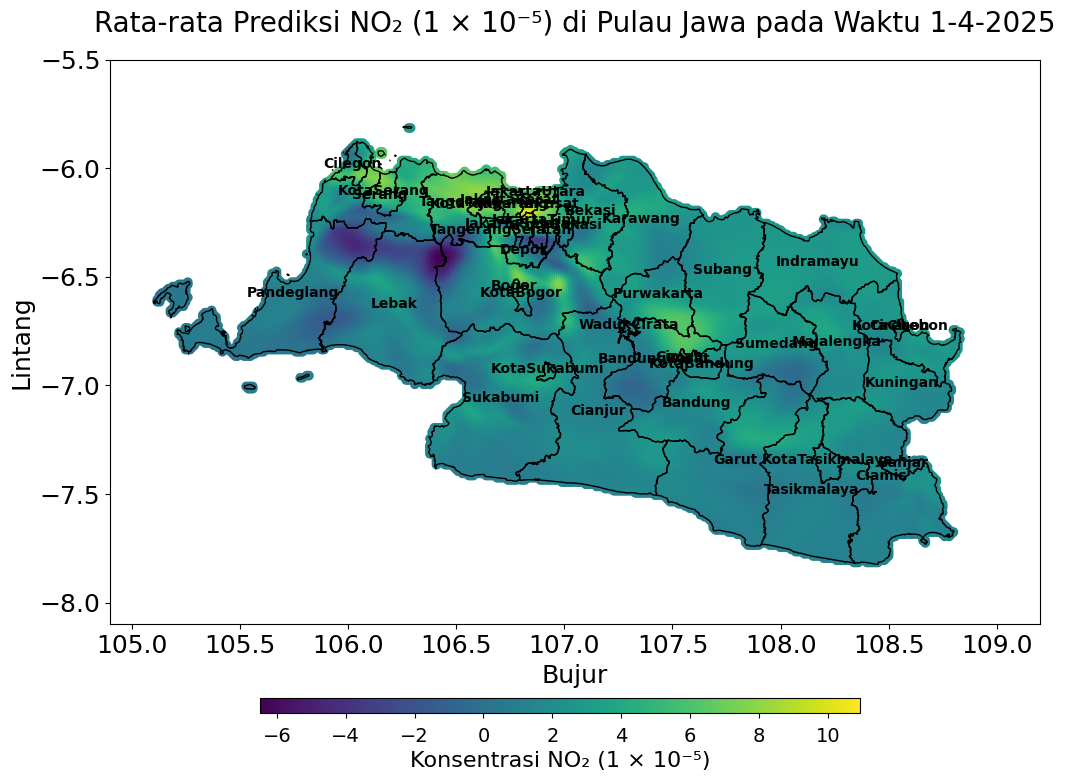

In [88]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- 2. Filter Data by Time ---
# Choose a specific time 't' to visualize
time_to_visualize = t  # Example: Visualize predictions at time step 365

filtered_prediction_df = prediction_df[prediction_df['t'] == time_to_visualize].copy()
if filtered_prediction_df.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {filtered_prediction_df.shape}")
    display(filtered_prediction_df.head())

    # --- 3. Prepare Geographical Data ---
    indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

    jawa_provinces = df.city.unique()
    jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]

    # --- 4. Merge Data ---
    geometry = [Point(xy) for xy in zip(filtered_prediction_df['x'], filtered_prediction_df['y'])]
    prediction_gdf = gpd.GeoDataFrame(filtered_prediction_df, geometry=geometry)

    merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())

    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(figsize=(12, 7.5))

    # Plot Java map
    jawa.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot predicted NO₂
    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, cmap='viridis')

    # --- Draw boundaries and add labels ---
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)
    jawa['centroid'] = jawa.geometry.centroid

    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=10,
            color='black',
            weight='bold'
        )

    # --- Colorbar ---
    cax = fig.add_axes([0.25, 0, 0.5, 0.02])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=merged_gdf['prediction'].min(),
                           vmax=merged_gdf['prediction'].max())
    )
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Konsentrasi NO₂ (1 × 10⁻⁵)', fontsize=16)
    cbar.ax.tick_params(labelsize=14,pad=6)

    # --- Titles and labels ---
    ax.set_title(
        f'Rata-rata Prediksi NO₂ (1 × 10⁻⁵) di Pulau Jawa pada Waktu {target_day}-{target_month}-{target_year}',
        fontsize=20, pad=20
    )
    ax.set_xlabel('Bujur', fontsize=18)
    ax.set_ylabel('Lintang', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

    # --- Region limits ---
    ax.set_xlim(104.9, 109.2)
    ax.set_ylim(-8.1, -5.5)

    plt.show()


In [97]:
from datetime import datetime, timedelta

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
# Example: input day, month, year
target_day = 26
target_month = 4
target_year = 2025

# --- Step 3: Create the target date object ---
target_date = datetime(target_year, target_month, target_day)

# --- Step 4: Compute the number of days since start_date ---
t = (target_date - start_date).days

# --- Step 5: Print the result ---
print("t =", t)


t = 726


Filtered prediction data for time = 726. Shape: (94705, 4)


,t,x,y,prediction
68755830,726,104.968,-7.96479,-2.00689
68755831,726,104.968,-7.95479,-2.40242
68755832,726,104.968,-7.94479,-2.86551
68755833,726,104.968,-7.93479,-3.37782
68755834,726,104.968,-7.92479,-3.90285



Merged GeoDataFrame:


/tmp/ipython-input-1685745464.py:29: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")


,t,x,y,prediction,geometry,index_right,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
68759490,726,105.118,-6.61476,1.03623,POINT (105.118 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759491,726,105.118,-6.60476,1.04353,POINT (105.118 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759725,726,105.129,-6.61476,1.02052,POINT (105.129 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759726,726,105.129,-6.60476,1.03157,POINT (105.129 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759727,726,105.129,-6.59476,1.03539,POINT (105.129 -6.59476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA


/tmp/ipython-input-1685745464.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


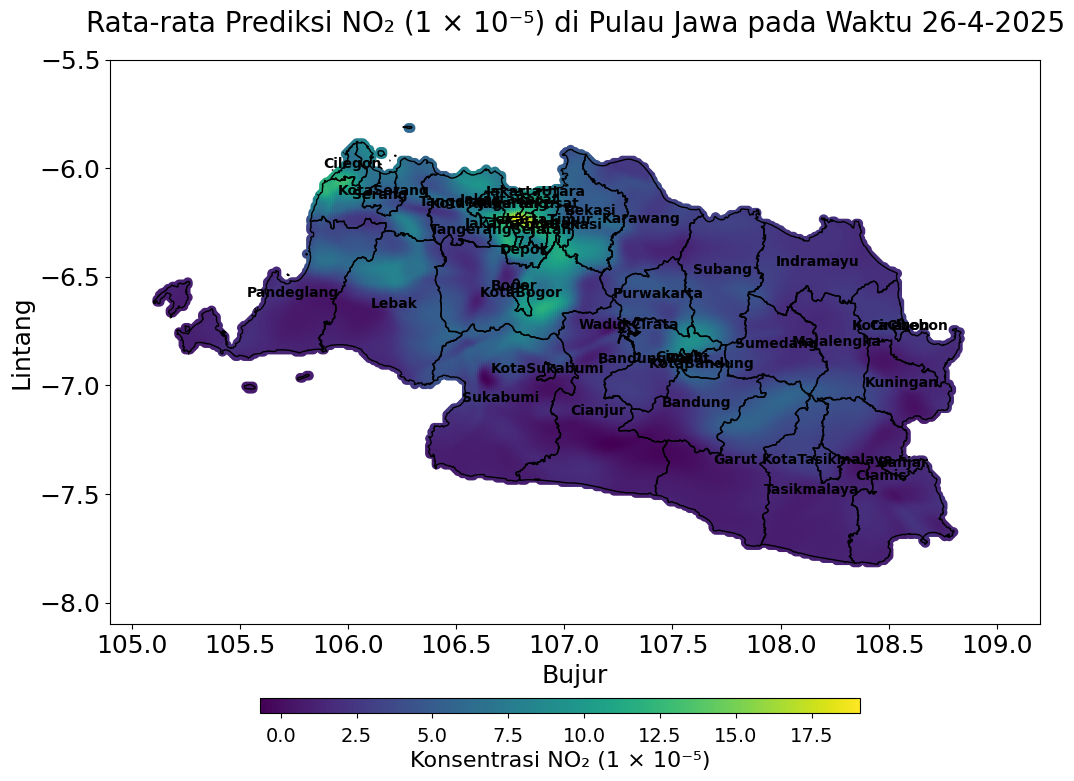

In [101]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- 2. Filter Data by Time ---
# Choose a specific time 't' to visualize
time_to_visualize = t  # Example: Visualize predictions at time step 365

# filtered_prediction_df = prediction_df[prediction_df['t'] == time_to_visualize].copy()
if filtered_prediction_df.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {filtered_prediction_df.shape}")
    display(filtered_prediction_df.head())

    # --- 3. Prepare Geographical Data ---
    indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

    jawa_provinces = df.city.unique()
    jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]

    # --- 4. Merge Data ---
    geometry = [Point(xy) for xy in zip(filtered_prediction_df['x'], filtered_prediction_df['y'])]
    prediction_gdf = gpd.GeoDataFrame(filtered_prediction_df, geometry=geometry)

    merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())

    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(figsize=(12, 7.5))

    # Plot Java map
    jawa.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot predicted NO₂
    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, cmap='viridis')

    # --- Draw boundaries and add labels ---
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)
    jawa['centroid'] = jawa.geometry.centroid

    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=10,
            color='black',
            weight='bold'
        )

    # --- Colorbar ---
    cax = fig.add_axes([0.25, 0, 0.5, 0.02])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=merged_gdf['prediction'].min(),
                           vmax=merged_gdf['prediction'].max())
    )
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Konsentrasi NO₂ (1 × 10⁻⁵)', fontsize=16)
    cbar.ax.tick_params(labelsize=14,pad=6)

    # --- Titles and labels ---
    ax.set_title(
        f'Rata-rata Prediksi NO₂ (1 × 10⁻⁵) di Pulau Jawa pada Waktu {target_day}-{target_month}-{target_year}',
        fontsize=20, pad=20
    )
    ax.set_xlabel('Bujur', fontsize=18)
    ax.set_ylabel('Lintang', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

    # --- Region limits ---
    ax.set_xlim(104.9, 109.2)
    ax.set_ylim(-8.1, -5.5)

    plt.show()


In [91]:
unique_coords = filtered_df[["x_coord", "y_coord"]].round(6).drop_duplicates().reset_index(drop=True)
display(unique_coords)
t_points = np.arange(filtered_df["time"].min(), filtered_df["time"].max() + 1, 1)
xy_points = unique_coords
xy_points = unique_coords[['x_coord', 'y_coord']].to_numpy()

time_col = np.repeat(t_points, len(xy_points), axis=0)

# 2. Tile the entire block of xy pairs for the number of time points
coords_block = np.tile(xy_points, (len(t_points), 1))

# 3. Combine them into the final prediction grid
# We reshape time_col to (N, 1) to stack it horizontally with the (N, 2) coords_block
prediction_grid = np.concatenate([time_col[:, np.newaxis], coords_block], axis=1)

print("Time points:", len(t_points))
print("Unique XY pairs:", len(xy_points))
print("Prediction grid shape:", prediction_grid.shape)

,x_coord,y_coord
0,107.610720,-7.100013
1,107.414924,-6.897186
2,108.566579,-7.376339
3,107.120699,-6.215191
4,106.767609,-6.559987
...,...,...
363,107.980880,-6.825126
364,106.518714,-6.174249
365,106.707481,-6.301754
366,108.141338,-7.497079


Time points: 730
Unique XY pairs: 368
Prediction grid shape: (268640, 3)


In [92]:
prediction_df = models_Adam_comb[1][0].predict(prediction_grid)

8395/8395 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


In [95]:
results_df = pd.DataFrame(prediction_grid, columns=['time', 'x_coord', 'y_coord'])
results_df['prediction'] = prediction_df

# In your results DataFrame
results_df['x_rounded'] = results_df['x_coord'].round(6)
results_df['y_rounded'] = results_df['y_coord'].round(6)

# In your original filtered DataFrame
filtered_df['x_rounded'] = filtered_df['x_coord'].round(6)
filtered_df['y_rounded'] = filtered_df['y_coord'].round(6)

merged_df = pd.merge(
    results_df,
    filtered_df[['time', 'x_rounded', 'y_rounded', 'NO2_filtered','city']], # Select only needed columns
    how='left',
    on=['time', 'x_rounded', 'y_rounded']
)
# merged_df = merged_df.drop(columns=['x_rounded', 'y_rounded'])

# Display the result
print(merged_df.head())
print(f"Original shape: {filtered_df.shape}")
print(f"Merged shape:   {merged_df.shape}")


city_lookup = filtered_df[['city', 'x_rounded', 'y_rounded']].copy()
city_lookup.drop_duplicates(subset=['x_rounded', 'y_rounded'], inplace=True)


merged_city = pd.merge(
    merged_df,
    city_lookup[['x_rounded', 'y_rounded', 'city']].rename(columns={'city': 'city_lookup'}),
    on=['x_rounded', 'y_rounded'],
    how='left'
)

merged_city['city'] = merged_city['city'].fillna(merged_city['city_lookup'])
merged_city = merged_city.drop(columns=['city_lookup'])
merged_city.drop(columns=['x_rounded', 'y_rounded'], inplace=True)


   time     x_coord   y_coord  prediction   x_rounded  y_rounded  \
0   0.0  107.610720 -7.100013    2.944994  107.610720  -7.100013   
1   0.0  107.414924 -6.897186    3.854639  107.414924  -6.897186   
2   0.0  108.566579 -7.376339    2.086886  108.566579  -7.376339   
3   0.0  107.120699 -6.215191    5.533652  107.120699  -6.215191   
4   0.0  106.767609 -6.559987    4.762383  106.767609  -6.559987   

   NO2_filtered          city  
0      2.922514       Bandung  
1      3.711394  BandungBarat  
2           NaN           NaN  
3      5.256398        Bekasi  
4      4.783558         Bogor  
Original shape: (191695, 9)
Merged shape:   (268640, 8)


In [104]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Konversi 't' ke format tanggal
start_date = pd.to_datetime("2023-05-01")
merged_city['tanggal'] = merged_city['time'].apply(lambda x: start_date + pd.Timedelta(days=int(x)))

# Ensure numeric types
merged_city['prediction'] = pd.to_numeric(merged_city['prediction'], errors='coerce')
merged_city['NO2_filtered'] = pd.to_numeric(merged_city['NO2_filtered'], errors='coerce')

# Drop any rows with missing values in the relevant columns
clean_df = merged_city.dropna(subset=['prediction', 'NO2_filtered', 'city']).copy()

# Group by city and compute MAE and MAPE
city_metrics = clean_df.groupby('city').apply(
    lambda g: pd.Series({
        'MAE': np.mean(np.abs(g['prediction'] - g['NO2_filtered'])),
        'MAPE': np.mean(np.abs((g['prediction'] - g['NO2_filtered']) / g['NO2_filtered'])) * 100
    })
).reset_index()

# Display nicely
print(city_metrics.sort_values(by='MAPE',ascending=False))

                city       MAE       MAPE
22       KotaCirebon  0.529011  13.752689
39       Tasikmalaya  0.104719   8.737281
9            Cirebon  0.218051   7.804767
32               Sea  0.137652   7.439436
5             Ciamis  0.102871   7.172100
30        Pandeglang  0.115549   6.535437
2             Banjar  0.110133   6.152216
27          Kuningan  0.122340   6.121335
26   KotaTasikmalaya  0.107409   6.064631
11             Garut  0.085450   6.040913
12         Indramayu  0.164831   6.018537
6            Cianjur  0.103950   5.583557
24      KotaSukabumi  0.167443   5.574621
36          Sumedang  0.130633   5.448949
28             Lebak  0.129864   5.158271
34            Subang  0.165507   5.141284
35          Sukabumi  0.096238   4.929921
18          Karawang  0.169165   4.926403
31        Purwakarta  0.185326   4.810521
29        Majalengka  0.128242   4.784264
0            Bandung  0.118332   4.031922
19       KotaBandung  0.171882   4.029012
7            Cilegon  0.321949   4

/tmp/ipython-input-4069207861.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_metrics = clean_df.groupby('city').apply(


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Konversi 't' ke format tanggal
start_date = pd.to_datetime("2023-05-01")
merged_city['tanggal'] = merged_city['time'].apply(lambda x: start_date + pd.Timedelta(days=int(x)))

# Daftar kota unik
cities = merged_city['city'].unique()

# Pengaturan font
plt.rcParams.update({'font.size': 14})

# Plot untuk setiap kota
for city in cities:
    df_city = merged_city[merged_city['city'] == city]

    plt.figure(figsize=(12, 4))
    plt.plot(df_city['tanggal'], df_city['prediction'], label='Prediksi NO₂', color='blue')
    plt.plot(df_city['tanggal'], df_city['NO2_filtered'], label='NO₂ Teramati (Hasil Pre-Processing)', color='orange')

    plt.title(f'Perbandingan Konsentrasi NO₂ Teramati dan Hasil Prediksi PINN di {city}', fontsize=14)
    plt.xlabel('Tanggal', fontsize=14)
    plt.ylabel('Konsentrasi NO₂ (10⁻² mol/m²)', fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.